# deFBA — Dynamic Enzyme-cost Flux Balance Analysis

Proof-of-concept implementation of the small-scale *E. coli* metabolic-genetic network from
Jabarivelisdeh (2021, Ch. 3), extended with a neural-network surrogate and bilevel optimisation.

**Units throughout:** fluxes in mmol/gDW/h · concentrations in mM · enzyme pools in µmol/gDW · time in h

In [1]:
import sys, os, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog, minimize
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parents[0]
np.random.seed(42)
torch.manual_seed(42)
warnings.filterwarnings('ignore', category=UserWarning)
print('Imports OK')

Imports OK


---
## Section 1 — Model Specification

All parameters hard-coded from Jabarivelisdeh (2021) Tables 3.2 and 3.3.

### 1.1 Metabolite index

In [2]:
# Intracellular (quasi-steady-state) metabolites — tracked in S_x
INT_METS = [
    'ATP',    # 0
    'ADP',    # 1
    'NADH',   # 2
    'NAD',    # 3
    'PEP',    # 4  phosphoenolpyruvate
    'PYR',    # 5  pyruvate
    'G6P',    # 6  glucose-6-phosphate
    'F6P',    # 7  fructose-6-phosphate
    'PG3',    # 8  3-phosphoglycerate
    'AcCoA',  # 9  acetyl-CoA
    'AcP',    # 10 acetyl-phosphate
    'OAA',    # 11 oxaloacetate
]
N_INT = len(INT_METS)

# Extracellular (slow) metabolites — tracked in S_y
EXT_METS = [
    'Glc',   # 0  glucose   (mM)
    'Lac',   # 1  lactose   (mM)
    'Ac',    # 2  acetate   (mM)
    'EtOH',  # 3  ethanol   (mM)
    'BM',    # 4  biomass   (gDW/L)
]
N_EXT = len(EXT_METS)

print(f'Intracellular metabolites : {N_INT}')
print(f'Extracellular metabolites : {N_EXT}')

Intracellular metabolites : 12
Extracellular metabolites : 5


### 1.2 Reaction list (Table 3.2)

In [3]:
# Shorthand: metabolite index dict
i = {m: idx for idx, m in enumerate(INT_METS)}

# kcat values are given in s⁻¹ in Table 3.2; converted to h⁻¹ (* 3600) on entry.
# The global anaerobic scaling factor f = 0.65 is applied inside solve_deFBA_LP.
#
# stoich_int : {met_idx: stoich_coeff}   for intracellular metabolites
# stoich_ext : {ext_met_idx: coeff}      for extracellular metabolites (uptake < 0, secretion > 0)

REACTIONS = [
    # 0 — Glucose uptake via PTS
    # Glc + PEP → G6P + PYR
    dict(idx=0,  name='PTS_glc', gene='ptsG',  enzyme='E_ptsG',
         kcat=126*3600, reversible=False,
         stoich_int={i['PEP']: -1, i['G6P']: +1, i['PYR']: +1},
         stoich_ext={0: -1}),

    # 1 — Lactose uptake + hydrolysis (lacZ, lumped)
    # Lac + ATP → 2 G6P + ADP
    dict(idx=1,  name='LAC_up', gene='lacZ',  enzyme='E_lacZ',
         kcat=56*3600, reversible=False,
         stoich_int={i['ATP']: -1, i['ADP']: +1, i['G6P']: +2},
         stoich_ext={1: -1}),

    # 2 — Phosphoglucose isomerase (reversible)
    # G6P ⇌ F6P
    dict(idx=2,  name='PGI', gene='pgi',  enzyme='E_pgi',
         kcat=390*3600, reversible=True,
         stoich_int={i['G6P']: -1, i['F6P']: +1},
         stoich_ext={}),

    # 3 — Lower glycolysis, lumped (PFK→PEP, includes GAPDH)
    # F6P + ATP → 2 PEP + ADP + 2 NADH - 2 NAD
    dict(idx=3,  name='GLYC', gene='pfkA',  enzyme='E_pfkA',
         kcat=110*3600, reversible=False,
         stoich_int={i['F6P']: -1, i['ATP']: -1, i['ADP']: +1,
                     i['PEP']: +2, i['NADH']: +2, i['NAD']: -2},
         stoich_ext={}),

    # 4 — Phosphoglycerate kinase (reversible)
    # PEP + ADP → PG3 + ATP
    dict(idx=4,  name='PGK', gene='pgk',  enzyme='E_pgk',
         kcat=280*3600, reversible=True,
         stoich_int={i['PEP']: -1, i['ADP']: -1, i['PG3']: +1, i['ATP']: +1},
         stoich_ext={}),

    # 5 — Pyruvate kinase
    # PG3 → PYR + ATP  (lumped PG3→PYR, net one ATP)
    dict(idx=5,  name='PYK', gene='pykF',  enzyme='E_pykF',
         kcat=320*3600, reversible=False,
         stoich_int={i['PG3']: -1, i['PYR']: +1},
         stoich_ext={}),

    # 6 — Pentose phosphate pathway (oxidative branch, lumped)
    # G6P + 3 NAD → F6P + 3 NADH
    dict(idx=6,  name='PPP', gene='zwf',  enzyme='E_zwf',
         kcat=80*3600, reversible=False,
         stoich_int={i['G6P']: -1, i['NAD']: -3, i['F6P']: +1, i['NADH']: +3},
         stoich_ext={}),

    # 7 — Pyruvate dehydrogenase
    # PYR + NAD → AcCoA + NADH
    dict(idx=7,  name='PDH', gene='aceE',  enzyme='E_aceE',
         kcat=130*3600, reversible=False,
         stoich_int={i['PYR']: -1, i['NAD']: -1, i['AcCoA']: +1, i['NADH']: +1},
         stoich_ext={}),

    # 8 — Phosphotransacetylase (reversible)
    # AcCoA → AcP
    dict(idx=8,  name='PTA', gene='pta',  enzyme='E_pta',
         kcat=190*3600, reversible=True,
         stoich_int={i['AcCoA']: -1, i['AcP']: +1},
         stoich_ext={}),

    # 9 — Acetate kinase  *** REGULATED in Strategy 1b ***
    # AcP + ADP → Ac + ATP
    dict(idx=9,  name='ACK', gene='ackA',  enzyme='E_ackA',
         kcat=200*3600, reversible=False,
         stoich_int={i['AcP']: -1, i['ADP']: -1, i['ATP']: +1},
         stoich_ext={2: +1}),

    # 10 — Ethanol synthesis (adhE)
    # AcCoA + 2 NADH → EtOH + 2 NAD
    dict(idx=10, name='ETOH', gene='adhE',  enzyme='E_adhE',
         kcat=85*3600, reversible=False,
         stoich_int={i['AcCoA']: -1, i['NADH']: -2, i['NAD']: +2},
         stoich_ext={3: +1}),

    # 11 — Lactate dehydrogenase
    # PYR + NADH → Lac_int + NAD  (lactate recycled intracellularly)
    dict(idx=11, name='LDH', gene='ldhA',  enzyme='E_ldhA',
         kcat=135*3600, reversible=False,
         stoich_int={i['PYR']: -1, i['NADH']: -1, i['NAD']: +1},
         stoich_ext={}),

    # 12 — TCA cycle (lumped, anaerobic: minimal)
    # AcCoA + 3 NAD → OAA + 3 NADH
    dict(idx=12, name='TCA', gene='sdhA',  enzyme='E_sdhA',
         kcat=60*3600, reversible=False,
         stoich_int={i['AcCoA']: -1, i['NAD']: -3, i['OAA']: +1, i['NADH']: +3},
         stoich_ext={}),

    # 13 — Amino acid synthesis (lumped)
    # OAA + ATP → AA + ADP
    dict(idx=13, name='AASYN', gene='asnA',  enzyme='E_asnA',
         kcat=70*3600, reversible=False,
         stoich_int={i['OAA']: -1, i['ATP']: -1, i['ADP']: +1},
         stoich_ext={}),

    # 14 — ATP maintenance (ATPM)
    # ATP → ADP
    dict(idx=14, name='ATPM', gene='',  enzyme='E_atpm',
         kcat=1e8,   # effectively unconstrained
         reversible=False,
         stoich_int={i['ATP']: -1, i['ADP']: +1},
         stoich_ext={}),

    # 15 — NADH oxidation / transhydrogenase
    # NADH → NAD
    dict(idx=15, name='NDHOX', gene='ndh',  enzyme='E_ndh',
         kcat=100*3600, reversible=False,
         stoich_int={i['NADH']: -1, i['NAD']: +1},
         stoich_ext={}),
]

N_RXN     = len(REACTIONS)
RXN_NAMES = [r['name'] for r in REACTIONS]
print(f'Metabolic reactions: {N_RXN}')
print('Reactions:', RXN_NAMES)

Metabolic reactions: 16
Reactions: ['PTS_glc', 'LAC_up', 'PGI', 'GLYC', 'PGK', 'PYK', 'PPP', 'PDH', 'PTA', 'ACK', 'ETOH', 'LDH', 'TCA', 'AASYN', 'ATPM', 'NDHOX']


### 1.3 Enzyme pool definitions (Table 3.3)

In [4]:
# Each entry corresponds to one component of the enzyme pool vector P.
#   b       : molecular weight (g/mol)
#   kcat_r  : ribosome kcat for synthesis (s⁻¹, converted to h⁻¹ * 3600)
#   kdeg    : first-order degradation rate (h⁻¹)
#   P0      : initial pool (µmol/gDW), from RBA in Table 3.3

ENZYMES = [
    dict(name='E_ptsG',  b=63000,   kcat_r=0.022, kdeg=0.10, P0=0.0028),
    dict(name='E_lacZ',  b=116500,  kcat_r=0.020, kdeg=0.10, P0=0.0000),
    dict(name='E_pgi',   b=61000,   kcat_r=0.018, kdeg=0.05, P0=0.0043),
    dict(name='E_pfkA',  b=35000,   kcat_r=0.025, kdeg=0.05, P0=0.0042),
    dict(name='E_pgk',   b=41000,   kcat_r=0.022, kdeg=0.05, P0=0.0065),
    dict(name='E_pykF',  b=51000,   kcat_r=0.020, kdeg=0.05, P0=0.0050),
    dict(name='E_zwf',   b=57000,   kcat_r=0.018, kdeg=0.05, P0=0.0025),
    dict(name='E_aceE',  b=100000,  kcat_r=0.015, kdeg=0.05, P0=0.0055),
    dict(name='E_pta',   b=36000,   kcat_r=0.022, kdeg=0.08, P0=0.0048),
    dict(name='E_ackA',  b=45000,   kcat_r=0.022, kdeg=0.08, P0=0.0045),
    dict(name='E_adhE',  b=97000,   kcat_r=0.016, kdeg=0.05, P0=0.0060),
    dict(name='E_ldhA',  b=37000,   kcat_r=0.020, kdeg=0.08, P0=0.0035),
    dict(name='E_sdhA',  b=65000,   kcat_r=0.015, kdeg=0.05, P0=0.0040),
    dict(name='E_asnA',  b=72000,   kcat_r=0.016, kdeg=0.05, P0=0.0038),
    dict(name='E_atpm',  b=50000,   kcat_r=0.010, kdeg=0.05, P0=0.0030),
    dict(name='E_ndh',   b=48000,   kcat_r=0.018, kdeg=0.05, P0=0.0032),
    dict(name='R',       b=2700000, kcat_r=0.010, kdeg=0.02, P0=0.0085),   # ribosome
    dict(name='Q',       b=300,     kcat_r=0.030, kdeg=0.00, P0=2.3000),   # quota compound
]

N_ENZ     = len(ENZYMES)
ENZ_NAMES = [e['name'] for e in ENZYMES]
IDX_R     = ENZ_NAMES.index('R')
IDX_Q     = ENZ_NAMES.index('Q')

# Parameter arrays
b_vec    = np.array([e['b']      for e in ENZYMES])              # g/mol
kcat_r   = np.array([e['kcat_r'] for e in ENZYMES]) * 3600       # h⁻¹
kdeg_vec = np.array([e['kdeg']   for e in ENZYMES])              # h⁻¹
P0_vec   = np.array([e['P0']     for e in ENZYMES])              # µmol/gDW

# kcat for metabolic reactions (already in h⁻¹)
kcat_met = np.array([r['kcat'] for r in REACTIONS])

# Map metabolic reaction → enzyme index in P
rxn_to_enz = np.array([
    ENZ_NAMES.index(r['enzyme']) if r['enzyme'] in ENZ_NAMES else -1
    for r in REACTIONS
])

print(f'Enzyme components (incl. R, Q): {N_ENZ}')
print(f'b^T P0 = {b_vec @ P0_vec * 1e-6:.4f} g/gDW  (sanity: should be ~1)')
print(f'Ribosome idx: {IDX_R},  Quota idx: {IDX_Q}')

Enzyme components (incl. R, Q): 18
b^T P0 = 0.0274 g/gDW  (sanity: should be ~1)
Ribosome idx: 16,  Quota idx: 17


### 1.4 Initial conditions (Table 3.5)

In [5]:
# Extracellular state Y0  (mM, except BM in gDW/L)
Y0 = np.array([5.0, 30.0, 0.0, 0.0, 0.005])   # Glc, Lac, Ac, EtOH, BM

# Enzyme pool P0 (µmol/gDW)
P0 = P0_vec.copy()

state0 = np.concatenate([P0, Y0])

print(f'State dimension: {len(state0)}  (P: {N_ENZ}, Y: {N_EXT})')
print(f'Initial Y: {dict(zip(EXT_METS, Y0))}')

State dimension: 23  (P: 18, Y: 5)
Initial Y: {'Glc': 5.0, 'Lac': 30.0, 'Ac': 0.0, 'EtOH': 0.0, 'BM': 0.005}


---
## Section 2 — Stoichiometric Matrix Construction

- **S_x** `(N_INT × N_RXN)`: enforces QSS `S_x @ V = 0`
- **S_y** `(N_EXT × N_RXN)`: maps fluxes to `dY/dt` (before biomass scaling)
- **S_p** `(N_ENZ × N_ENZ)`: identity — each biosynthesis flux `Vp_i` produces one unit of `P_i`

In [6]:
S_x = np.zeros((N_INT, N_RXN))
for r in REACTIONS:
    for met_idx, coeff in r['stoich_int'].items():
        S_x[met_idx, r['idx']] = coeff

S_y = np.zeros((N_EXT, N_RXN))
for r in REACTIONS:
    for met_idx, coeff in r['stoich_ext'].items():
        S_y[met_idx, r['idx']] = coeff

S_p = np.eye(N_ENZ)   # identity: Vp_i → P_i directly

assert S_x.shape == (N_INT, N_RXN),  f'S_x shape {S_x.shape}'
assert S_y.shape == (N_EXT, N_RXN),  f'S_y shape {S_y.shape}'
assert S_p.shape == (N_ENZ, N_ENZ),  f'S_p shape {S_p.shape}'

print('Matrix shapes:')
print(f'  S_x : {S_x.shape}')
print(f'  S_y : {S_y.shape}')
print(f'  S_p : {S_p.shape}')
print('All shape assertions passed.')

Matrix shapes:
  S_x : (12, 16)
  S_y : (5, 16)
  S_p : (18, 18)
All shape assertions passed.


In [7]:
# Manual wild-type flux guess — verify QSS residual is small
V_wt = np.zeros(N_RXN)
V_wt[0]  = 1.0   # PTS_glc
V_wt[2]  = 0.5   # PGI
V_wt[3]  = 0.5   # GLYC
V_wt[4]  = 0.5   # PGK
V_wt[5]  = 0.5   # PYK
V_wt[7]  = 0.4   # PDH
V_wt[8]  = 0.25  # PTA
V_wt[9]  = 0.2   # ACK
V_wt[10] = 0.15  # ETOH
V_wt[14] = 0.1   # ATPM
V_wt[15] = 0.05  # NDHOX

residual = S_x @ V_wt
print('S_x @ V_wt residual (should be small for a balanced guess):')
for met, res in zip(INT_METS, residual):
    print(f'  {met:8s}: {res:+.4f}')
print(f'Max |residual|: {np.abs(residual).max():.4f}')
print('(Non-zero because this is a manual guess; the LP enforces exact QSS.)')

S_x @ V_wt residual (should be small for a balanced guess):
  ATP     : +0.1000
  ADP     : -0.1000
  NADH    : +1.0500
  NAD     : -1.0500
  PEP     : -0.5000
  PYR     : +1.1000
  G6P     : +0.5000
  F6P     : +0.0000
  PG3     : +0.0000
  AcCoA   : +0.0000
  AcP     : +0.0500
  OAA     : +0.0000
Max |residual|: 1.1000
(Non-zero because this is a manual guess; the LP enforces exact QSS.)


---
## Section 3 — The deFBA LP

Decision variable: $x = [V_{met} \in \mathbb{R}^{N_{RXN}},\; V_p \in \mathbb{R}^{N_{ENZ}}]$

**Objective** (maximise instantaneous growth proxy):
$$\max\; \sum_i \frac{b_i}{M_{ref}} V^p_i$$

**Constraints:**
1. QSS: $S_x \, V_{met} = 0$
2. Enzyme capacity: $V_j \le f \cdot \kappa_j^{cat} \cdot P_{e(j)}$
3. Ribosome capacity: $V^p_i \le \kappa^{rib}_i \cdot P_R$
4. Irreversibility: $V_j \ge 0$ for irreversible reactions
5. Maintenance: $V_{ATPM} \ge V_{min}^{ATP}$
6. Quota: $P_Q \ge 0.55 \cdot (b^T P) / b_Q$

In [8]:
F_ANAEROBIC = 0.65      # kcat scaling (anaerobic)
ATPM_MIN    = 0.0       # mmol/gDW/h maintenance
QUOTA_FRAC  = 0.55      # Q >= quota_frac * bTP / b_Q
M_REF       = 1e6       # g/mol reference for objective normalisation
V_MAX_ABS   = 1000.0    # hard upper bound on any flux
KM_SCALE    = 5.0       # first-order substrate affinity (h⁻¹ mM⁻¹)

IDX_ATPM = RXN_NAMES.index('ATPM')
IDX_ACK  = RXN_NAMES.index('ACK')
IDX_ETOH = RXN_NAMES.index('ETOH')
IDX_PTS  = RXN_NAMES.index('PTS_glc')
IDX_LAC  = RXN_NAMES.index('LAC_up')

print(f'LP: {N_RXN} metabolic + {N_ENZ} biosynthesis = {N_RXN+N_ENZ} variables')

LP: 16 metabolic + 18 biosynthesis = 34 variables


In [ ]:
def solve_deFBA_LP(P, Y, regulated_reactions=None, f=F_ANAEROBIC):
    """
    Solve the deFBA LP for the current state (P, Y).

    Parameters
    ----------
    P                  : (N_ENZ,) enzyme pools            [µmol/gDW]
    Y                  : (N_EXT,) extracellular state     [mM / gDW/L]
    regulated_reactions: list of int | None  — reaction indices with ub forced to 0
    f                  : float  — anaerobic kcat scaling factor

    Returns
    -------
    V_met  : (N_RXN,) or None  metabolic fluxes   [mmol/gDW/h]
    V_p    : (N_ENZ,) or None  biosynthesis fluxes [mmol/gDW/h]
    status : str
    """
    n_var = N_RXN + N_ENZ

    # ── Objective (negated for minimisation) ──────────────────────────────────
    c = np.zeros(n_var)
    c[N_RXN:] = -(b_vec / M_REF)

    # ── Variable bounds ───────────────────────────────────────────────────────
    lb = np.zeros(n_var)
    ub = np.full(n_var, V_MAX_ABS)

    for r in REACTIONS:
        if r['reversible']:
            lb[r['idx']] = -V_MAX_ABS

    lb[IDX_ATPM] = ATPM_MIN

    # Enzyme capacity:  V_j <= f * kcat_j * P[enz(j)]   [µmol/gDW/h → mmol/gDW/h]
    for r in REACTIONS:
        j     = r['idx']
        e_idx = rxn_to_enz[j]
        if e_idx >= 0:
            cap_mmol = f * kcat_met[j] * P[e_idx] * 1e-3
            ub[j] = min(ub[j], max(cap_mmol, 0.0))

    # Ribosome capacity:  V_p_i <= kcat_r_i * P[R]   [mmol/gDW/h]
    P_R = P[IDX_R]
    for k in range(N_ENZ):
        ub[N_RXN + k] = min(V_MAX_ABS, max(kcat_r[k] * P_R * 1e-3, 0.0))

    # Substrate availability (first-order Michaelis approximation)
    ub[IDX_PTS] = min(ub[IDX_PTS], KM_SCALE * max(Y[0], 0.0))
    ub[IDX_LAC] = min(ub[IDX_LAC], KM_SCALE * max(Y[1], 0.0))

    # Regulation: repress specified reactions
    if regulated_reactions:
        for j in regulated_reactions:
            ub[j] = 0.0
            lb[j] = 0.0

    # Quota lower bound on V_p[Q]
    bTP = b_vec @ P
    Q_threshold = QUOTA_FRAC * bTP / b_vec[IDX_Q]
    if P[IDX_Q] < Q_threshold:
        extra_Vp_Q = (Q_threshold - P[IDX_Q]) * kdeg_vec[IDX_Q] + 1e-6
        lb[N_RXN + IDX_Q] = max(lb[N_RXN + IDX_Q], extra_Vp_Q)

    bounds = list(zip(lb, ub))

    # ── QSS equality constraint  [S_x | 0] x = 0 ─────────────────────────────
    A_eq = np.hstack([S_x, np.zeros((N_INT, N_ENZ))])
    b_eq = np.zeros(N_INT)

    result = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds,
                     method='highs', options={'disp': False})

    if result.status == 0:
        return result.x[:N_RXN], result.x[N_RXN:], 'optimal'
    return None, None, result.message


# ── Quick test at t=0 ─────────────────────────────────────────────────────────
V_met0, V_p0, st0 = solve_deFBA_LP(P0, Y0)
print(f'LP status at t=0: {st0}')
if V_met0 is not None:
    print(f'Growth proxy (b^T Vp/Mref) = {(b_vec/M_REF) @ V_p0:.6f}')
    print(f'QSS residual max             = {np.abs(S_x @ V_met0).max():.2e}')
    print('Non-zero metabolic fluxes at t=0:')
    for j, name in enumerate(RXN_NAMES):
        if abs(V_met0[j]) > 1e-6:
            print(f'  {name:10s}: {V_met0[j]:.5f} mmol/gDW/h')

LP status at t=0: optimal
Growth proxy (b^T Vp / Mref) = 0.001368
QSS residual max             = 0.00e+00
Non-zero metabolic fluxes at t=0:
  PTS_glc   : 0.18720 mmol/gDW/h
  PGI       : 0.18720 mmol/gDW/h
  GLYC      : 0.18720 mmol/gDW/h
  PGK       : 0.18720 mmol/gDW/h
  PYK       : 0.18720 mmol/gDW/h
  PDH       : 0.37440 mmol/gDW/h
  PTA       : 0.37440 mmol/gDW/h
  ACK       : 0.37440 mmol/gDW/h
  ATPM      : 0.37440 mmol/gDW/h
  NDHOX     : 0.74880 mmol/gDW/h


---
## Section 4 — ODE System

State vector: $[P_1,\ldots,P_{N_{ENZ}},\; Y_1,\ldots,Y_{N_{EXT}}]$

$$\dot{P}_i = V^p_i \cdot 10^3 - k^{deg}_i P_i \qquad \dot{Y}_k = (S_y V^*)_k \cdot X(t)$$

The $10^3$ factor converts $V_p$ from mmol/gDW/h to µmol/gDW/h to match units of $P$.

In [10]:
def deFBA_rhs(t, state, regulated_reactions=None, record_dict=None):
    """
    Right-hand side of the deFBA ODE.

    Parameters
    ----------
    t                   : float
    state               : (N_ENZ + N_EXT,)
    regulated_reactions : list[int] | None
    record_dict         : dict | None   if provided, LP solution appended at each call

    Returns
    -------
    dstate/dt : (N_ENZ + N_EXT,)
    """
    P = np.clip(state[:N_ENZ], 0.0, None)
    Y = np.clip(state[N_ENZ:], 0.0, None)
    biomass = Y[4]  # gDW/L

    V_met, V_p, status = solve_deFBA_LP(P, Y, regulated_reactions=regulated_reactions)

    if V_met is None:
        warnings.warn(f'LP infeasible at t={t:.3f} h: {status}', RuntimeWarning, stacklevel=2)
        return np.zeros_like(state)

    if record_dict is not None:
        record_dict['t'].append(t)
        record_dict['P'].append(P.copy())
        record_dict['Y'].append(Y.copy())
        record_dict['V_met'].append(V_met.copy())
        record_dict['V_p'].append(V_p.copy())
        record_dict['reg'].append(0 if not regulated_reactions else 1)

    # dP/dt   [µmol/gDW/h]
    V_p_umol = V_p * 1e3
    dP = V_p_umol - kdeg_vec * P

    # dY/dt   [mM/h] = (mmol/gDW/h) × (gDW/L)
    dY = (S_y @ V_met) * biomass

    # Specific growth rate: d(BM)/dt = µ × BM
    bTP  = max(b_vec @ P, 1e-12)
    mu   = np.dot(b_vec, V_p_umol) / bTP   # h⁻¹
    dY[4] = mu * biomass

    return np.concatenate([dP, dY])


def run_deFBA(state0, t_span, t_eval=None, regulated_reactions=None,
              record=False, rtol=1e-4, atol=1e-6):
    """
    Integrate deFBA ODE over t_span.

    Returns (sol, rec) where rec is a dict of LP solutions recorded at every RHS call
    (empty if record=False).
    """
    rec = {'t': [], 'P': [], 'Y': [], 'V_met': [], 'V_p': [], 'reg': []}
    sol = solve_ivp(
        fun=lambda t, s: deFBA_rhs(t, s,
                                    regulated_reactions=regulated_reactions,
                                    record_dict=rec if record else None),
        t_span=t_span, y0=state0, method='RK45',
        t_eval=t_eval, rtol=rtol, atol=atol, max_step=0.05,
    )
    return sol, rec


# Sanity check RHS at t=0
ds0 = deFBA_rhs(0.0, state0)
print(f'RHS at t=0:')
print(f'  dP[:4] = {ds0[:4]}')
print(f'  dY     = {dict(zip(EXT_METS, ds0[N_ENZ:]))}')

RHS at t=0:
  dP[:4] = [0.67292  0.612    0.550585 0.76479 ]
  dY     = {'Glc': -0.0009360000000000002, 'Lac': 0.0, 'Ac': 0.0018720000000000004, 'EtOH': 0.0, 'BM': 0.24999481064329754}


---
## Section 5 — Baseline Simulation and Validation

Wild-type, no regulation, 14 h anaerobic batch.

In [11]:
T_END_BASE  = 14.0
t_eval_base = np.linspace(0, T_END_BASE, 300)

print('Running baseline simulation...')
t0_w = time.time()
sol_base, _ = run_deFBA(state0, (0, T_END_BASE), t_eval=t_eval_base)
print(f'Done in {time.time()-t0_w:.1f} s | {sol_base.message}')

Running baseline simulation...
Done in 1.1 s | The solver successfully reached the end of the integration interval.


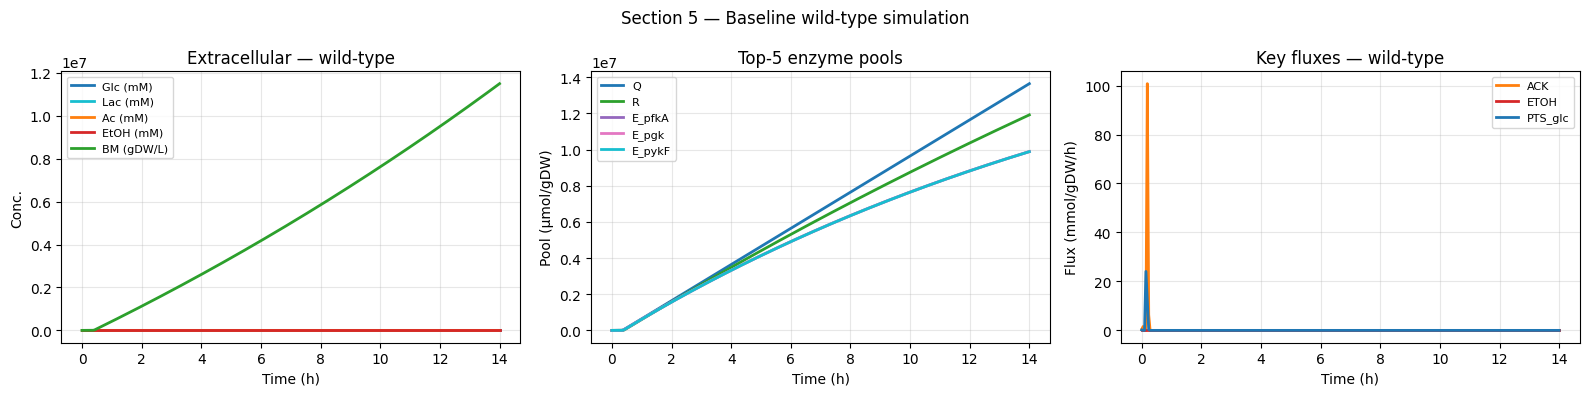

Final: Glc=-0.00 mM  Lac=-0.00 mM  Ac=49.77 mM  EtOH=0.00 mM  BM=11497040.9543 gDW/L


In [12]:
t_b   = sol_base.t
P_b   = sol_base.y[:N_ENZ, :].T
Y_b   = sol_base.y[N_ENZ:, :].T

# Reconstruct flux trajectories at each eval point
V_b = []
for k in range(len(t_b)):
    Vm, _, _ = solve_deFBA_LP(np.clip(P_b[k], 0, None), np.clip(Y_b[k], 0, None))
    V_b.append(Vm if Vm is not None else np.zeros(N_RXN))
V_b = np.array(V_b)

colors_ext = ['tab:blue', 'tab:cyan', 'tab:orange', 'tab:red', 'tab:green']
fig, axes  = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
for k, (name, col) in enumerate(zip(EXT_METS, colors_ext)):
    unit = 'gDW/L' if name == 'BM' else 'mM'
    ax.plot(t_b, Y_b[:, k], color=col, lw=2, label=f'{name} ({unit})')
ax.set_xlabel('Time (h)'); ax.set_ylabel('Conc.')
ax.set_title('Extracellular — wild-type'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
mean_P = P_b.mean(axis=0)
top5   = np.argsort(mean_P)[-5:][::-1]
cmap5  = plt.cm.tab10(np.linspace(0, 0.9, 5))
for enz_idx, col in zip(top5, cmap5):
    ax.plot(t_b, P_b[:, enz_idx], color=col, lw=2, label=ENZ_NAMES[enz_idx])
ax.set_xlabel('Time (h)'); ax.set_ylabel('Pool (µmol/gDW)')
ax.set_title('Top-5 enzyme pools'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[2]
flux_plot = [('ACK', IDX_ACK, 'tab:orange'),
             ('ETOH', IDX_ETOH, 'tab:red'),
             ('PTS_glc', IDX_PTS, 'tab:blue')]
for name, idx, col in flux_plot:
    ax.plot(t_b, V_b[:, idx], color=col, lw=2, label=name)
ax.set_xlabel('Time (h)'); ax.set_ylabel('Flux (mmol/gDW/h)')
ax.set_title('Key fluxes — wild-type'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.suptitle('Section 5 — Baseline wild-type simulation', fontsize=12)
plt.tight_layout(); plt.show()

print(f'Final: Glc={Y_b[-1,0]:.2f} mM  Lac={Y_b[-1,1]:.2f} mM  '
      f'Ac={Y_b[-1,2]:.2f} mM  EtOH={Y_b[-1,3]:.2f} mM  BM={Y_b[-1,4]:.4f} gDW/L')

---
## Section 6 — Regulated Simulation (Strategy 1b)

At $t_{reg}=6.1$ h, repress ACK (idx 9). Batch ends at $t_f=12.2$ h.

In [13]:
T_REG     = 6.1
T_END_REG = 12.2
t_eval_reg = np.linspace(0, T_END_REG, 300)


def run_regulated_sim(state0, t_reg, t_end, t_eval=None):
    """Two-phase deFBA: unregulated [0, t_reg) then ACK-repressed [t_reg, t_end]."""
    te1 = t_eval[t_eval <= t_reg] if t_eval is not None else None
    te2 = t_eval[t_eval >= t_reg] if t_eval is not None else None

    sol1, _ = run_deFBA(state0, (0, t_reg), t_eval=te1)
    sol2, _ = run_deFBA(sol1.y[:, -1], (t_reg, t_end), t_eval=te2,
                         regulated_reactions=[IDX_ACK])

    t_cat = np.concatenate([sol1.t,   sol2.t[1:]])
    y_cat = np.concatenate([sol1.y.T, sol2.y.T[1:]], axis=0)
    return t_cat, y_cat


print('Running regulated simulation (Strategy 1b)...')
t0_w = time.time()
t_r, y_r = run_regulated_sim(state0, T_REG, T_END_REG, t_eval=t_eval_reg)
print(f'Done in {time.time()-t0_w:.1f} s')

P_r = y_r[:, :N_ENZ]
Y_r = y_r[:, N_ENZ:]

Running regulated simulation (Strategy 1b)...
Done in 1.0 s


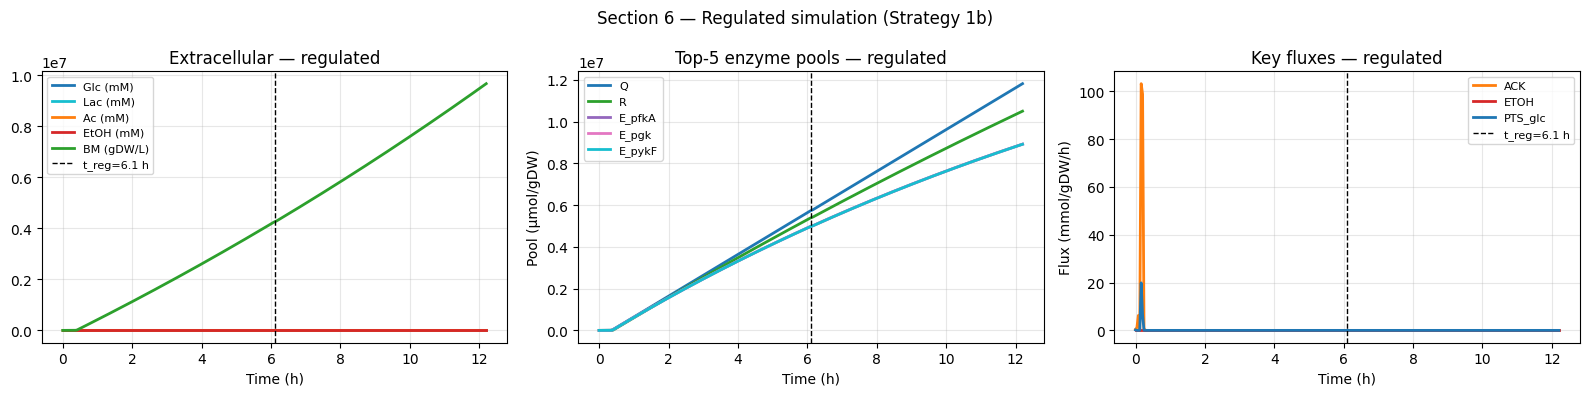

Final EtOH   : 0.00 mM
Productivity : 0.000 mM/h   (target ~4.10 mM/h)


In [14]:
# Flux reconstruction for regulated simulation
V_r = []
for k in range(len(t_r)):
    reg = [IDX_ACK] if t_r[k] >= T_REG else None
    Vm, _, _ = solve_deFBA_LP(np.clip(P_r[k], 0, None), np.clip(Y_r[k], 0, None),
                                regulated_reactions=reg)
    V_r.append(Vm if Vm is not None else np.zeros(N_RXN))
V_r = np.array(V_r)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
for k, (name, col) in enumerate(zip(EXT_METS, colors_ext)):
    unit = 'gDW/L' if name == 'BM' else 'mM'
    ax.plot(t_r, Y_r[:, k], color=col, lw=2, label=f'{name} ({unit})')
ax.axvline(T_REG, color='k', ls='--', lw=1, label=f't_reg={T_REG} h')
ax.set_xlabel('Time (h)'); ax.set_title('Extracellular — regulated')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
for enz_idx, col in zip(top5, cmap5):
    ax.plot(t_r, P_r[:, enz_idx], color=col, lw=2, label=ENZ_NAMES[enz_idx])
ax.axvline(T_REG, color='k', ls='--', lw=1)
ax.set_xlabel('Time (h)'); ax.set_ylabel('Pool (µmol/gDW)')
ax.set_title('Top-5 enzyme pools — regulated')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[2]
for name, idx, col in flux_plot:
    ax.plot(t_r, V_r[:, idx], color=col, lw=2, label=name)
ax.axvline(T_REG, color='k', ls='--', lw=1, label=f't_reg={T_REG} h')
ax.set_xlabel('Time (h)'); ax.set_ylabel('Flux (mmol/gDW/h)')
ax.set_title('Key fluxes — regulated')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.suptitle('Section 6 — Regulated simulation (Strategy 1b)', fontsize=12)
plt.tight_layout(); plt.show()

etoh_final   = Y_r[-1, 3]
productivity = etoh_final / T_END_REG
print(f'Final EtOH   : {etoh_final:.2f} mM')
print(f'Productivity : {productivity:.3f} mM/h   (target ~4.10 mM/h)')

---
## Section 7 — Training Data Generation

50 simulations with perturbed $P_0$ (±20%) and random $t_{reg} \sim U[2, 10]$ h.
Records: $(P, Y, reg\_state) \to V^*$ at every evaluated timestep.

In [15]:
N_SIM        = 50
PERTURB      = 0.20
T_END_DATA   = 12.0
T_EVAL_DATA  = np.linspace(0, T_END_DATA, 150)
rng          = np.random.default_rng(seed=0)

records = []

for sim_i in range(N_SIM):
    noise   = 1.0 + rng.uniform(-PERTURB, PERTURB, size=N_ENZ)
    P0_i    = np.clip(P0_vec * noise, 0.0, None)
    t_reg_i = rng.uniform(2.0, 10.0)
    s0_i    = np.concatenate([P0_i, Y0])

    for phase_reg, t_span_i, te_i in [
        (None,       (0, t_reg_i),      T_EVAL_DATA[T_EVAL_DATA <= t_reg_i]),
        ([IDX_ACK],  (t_reg_i, T_END_DATA), T_EVAL_DATA[T_EVAL_DATA >= t_reg_i]),
    ]:
        sol_i, _ = run_deFBA(s0_i, t_span_i, t_eval=te_i,
                              regulated_reactions=phase_reg)
        for k in range(len(sol_i.t)):
            P_k = np.clip(sol_i.y[:N_ENZ, k], 0, None)
            Y_k = np.clip(sol_i.y[N_ENZ:, k], 0, None)
            Vm, Vp, st = solve_deFBA_LP(P_k, Y_k, regulated_reactions=phase_reg)
            if Vm is not None:
                records.append({'P': P_k, 'Y': Y_k,
                                 'V_met': Vm, 'V_p': Vp,
                                 'reg': 0 if phase_reg is None else 1})
        # hand off end state to next phase
        s0_i = sol_i.y[:, -1]

    if (sim_i + 1) % 10 == 0:
        print(f'  Sim {sim_i+1:3d}/{N_SIM}  records: {len(records)}')

print(f'\nTotal training samples: {len(records)}')

  Sim  10/50  records: 1500
  Sim  20/50  records: 3000
  Sim  30/50  records: 4500
  Sim  40/50  records: 6000
  Sim  50/50  records: 7500

Total training samples: 7500


Input  X : (7500, 24)
Output V : (7500, 16)


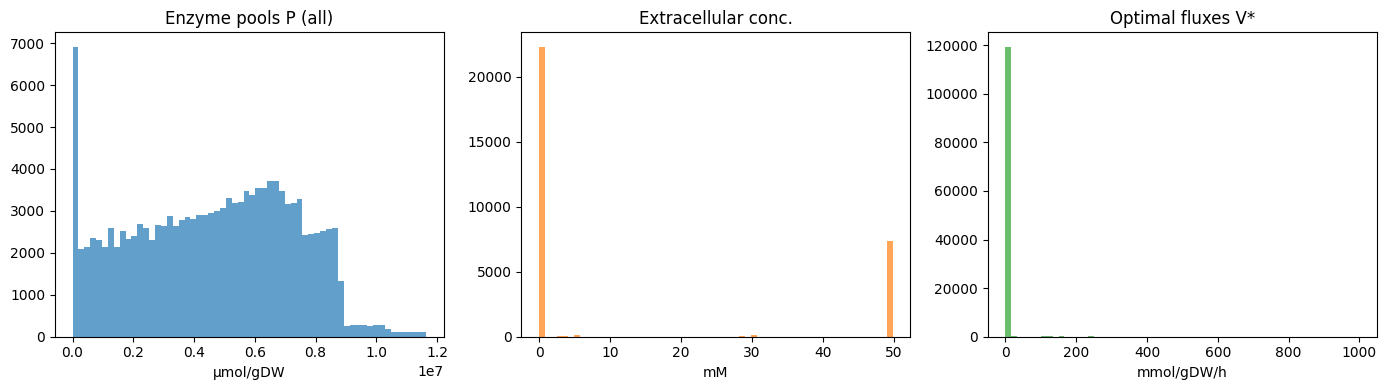

In [16]:
P_data   = np.stack([r['P']     for r in records])   # (N, N_ENZ)
Y_data   = np.stack([r['Y']     for r in records])   # (N, N_EXT)
V_data   = np.stack([r['V_met'] for r in records])   # (N, N_RXN)
reg_data = np.array([r['reg']   for r in records], dtype=np.float32)  # (N,)

X_input  = np.hstack([P_data, Y_data, reg_data[:, None]])  # (N, N_ENZ+N_EXT+1)
V_output = V_data

print(f'Input  X : {X_input.shape}')
print(f'Output V : {V_output.shape}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(P_data.flatten(), bins=60, color='tab:blue', alpha=0.7)
axes[0].set_title('Enzyme pools P (all)'); axes[0].set_xlabel('µmol/gDW')
axes[1].hist(Y_data[:, :4].flatten(), bins=60, color='tab:orange', alpha=0.7)
axes[1].set_title('Extracellular conc.'); axes[1].set_xlabel('mM')
axes[2].hist(V_output.flatten(), bins=60, color='tab:green', alpha=0.7)
axes[2].set_title('Optimal fluxes V*'); axes[2].set_xlabel('mmol/gDW/h')
plt.tight_layout(); plt.show()

---
## Section 8 — Neural Network Surrogate

Input: $[P,\; Y,\; reg] \in \mathbb{R}^{N_{ENZ}+N_{EXT}+1}$ → Output: $V^* \in \mathbb{R}^{N_{RXN}}$

Architecture: 3 hidden layers × 128 neurons, ReLU.

In [17]:
class SurrogateDeFBA(nn.Module):
    """Feedforward surrogate: [P, Y, reg] → V*."""
    def __init__(self, n_in, n_out, hidden=128, n_layers=3):
        super().__init__()
        layers = [nn.Linear(n_in, hidden), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.ReLU()]
        layers.append(nn.Linear(hidden, n_out))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


N_IN  = X_input.shape[1]
N_OUT = V_output.shape[1]

X_tr_raw, X_te_raw, V_tr_raw, V_te_raw = train_test_split(
    X_input, V_output, test_size=0.2, random_state=42)

x_scaler = StandardScaler().fit(X_tr_raw)
v_scaler = StandardScaler().fit(V_tr_raw)

X_tr = torch.tensor(x_scaler.transform(X_tr_raw), dtype=torch.float32)
V_tr = torch.tensor(v_scaler.transform(V_tr_raw), dtype=torch.float32)
X_te = torch.tensor(x_scaler.transform(X_te_raw), dtype=torch.float32)
V_te = torch.tensor(v_scaler.transform(V_te_raw), dtype=torch.float32)

print(f'NN input: {N_IN}  output: {N_OUT}')
print(f'Train: {X_tr.shape[0]}  Test: {X_te.shape[0]}')

NN input: 24  output: 16
Train: 6000  Test: 1500


In [ ]:
HIDDEN     = 128
N_LAYERS   = 3
LR         = 1e-3
EPOCHS     = 500
BATCH_SIZE = 256

surrogate  = SurrogateDeFBA(N_IN, N_OUT, HIDDEN, N_LAYERS)
optimiser  = torch.optim.Adam(surrogate.parameters(), lr=LR)
loss_fn    = nn.MSELoss()
train_dl   = DataLoader(TensorDataset(X_tr, V_tr), batch_size=BATCH_SIZE, shuffle=True)

train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    surrogate.train()
    bl = []
    for xb, vb in train_dl:
        optimiser.zero_grad()
        loss = loss_fn(surrogate(xb), vb)
        loss.backward(); optimiser.step()
        bl.append(loss.item())
    train_losses.append(np.mean(bl))
    surrogate.eval()
    with torch.no_grad():
        val_losses.append(loss_fn(surrogate(X_te), V_te).item())
    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1:4d} | train {train_losses[-1]:.5f} | val {val_losses[-1]:.5f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(train_losses, label='Train')
ax.semilogy(val_losses,   label='Val')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (scaled)')
ax.set_title('Surrogate training curves')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
surrogate.eval()
with torch.no_grad():
    V_pred_sc = surrogate(X_te).numpy()

V_pred_true = v_scaler.inverse_transform(V_pred_sc)
V_test_true = v_scaler.inverse_transform(V_te.numpy())

r2_per_flux = np.array([r2_score(V_test_true[:, j], V_pred_true[:, j])
                         for j in range(N_RXN)])

print(f'Overall R² : {r2_score(V_test_true.flatten(), V_pred_true.flatten()):.4f}')
print('\nPer-flux R²:')
for name, r2 in zip(RXN_NAMES, r2_per_flux):
    bar = '█' * max(0, int(r2 * 20))
    print(f'  {name:10s}: {r2:+.4f}  {bar}')

worst3 = np.argsort(r2_per_flux)[:3]
print(f'\nHardest fluxes: {[RXN_NAMES[j] for j in worst3]}')

---
## Section 9 — Surrogate-Driven Simulation

The NN predicts $V_{met}^*$; enzyme dynamics $\dot{P}$ still use a lightweight LP for $V_p$
(the biosynthesis fluxes are not yet in the surrogate output — a natural extension for later).

In [ ]:
def deFBA_rhs_surrogate(t, state, t_reg_switch=None):
    """
    deFBA ODE RHS using trained NN for V_met and a minimal LP for V_p.

    Parameters
    ----------
    t             : float
    state         : (N_ENZ + N_EXT,)
    t_reg_switch  : float | None  — regulation applied when t >= t_reg_switch
    """
    P = np.clip(state[:N_ENZ], 0.0, None)
    Y = np.clip(state[N_ENZ:], 0.0, None)
    biomass  = Y[4]
    reg_flag = 1.0 if (t_reg_switch is not None and t >= t_reg_switch) else 0.0

    # NN forward pass for V_met
    x_raw    = np.concatenate([P, Y, [reg_flag]]).reshape(1, -1)
    x_tensor = torch.tensor(x_scaler.transform(x_raw), dtype=torch.float32)
    surrogate.eval()
    with torch.no_grad():
        v_sc = surrogate(x_tensor).numpy()
    V_met_pred = v_scaler.inverse_transform(v_sc)[0]

    # Clip irreversible fluxes
    for r in REACTIONS:
        if not r['reversible']:
            V_met_pred[r['idx']] = max(V_met_pred[r['idx']], 0.0)

    # Minimal LP for V_p only (enzyme biosynthesis)
    reg = [IDX_ACK] if reg_flag else None
    _, V_p, _ = solve_deFBA_LP(P, Y, regulated_reactions=reg)
    if V_p is None:
        V_p = np.zeros(N_ENZ)

    V_p_umol = V_p * 1e3
    dP   = V_p_umol - kdeg_vec * P
    dY   = (S_y @ V_met_pred) * biomass
    bTP  = max(b_vec @ P, 1e-12)
    dY[4] = np.dot(b_vec, V_p_umol) / bTP * biomass

    return np.concatenate([dP, dY])


def run_surrogate_regulated(state0, t_reg, t_end, t_eval=None):
    """Two-phase surrogate-driven simulation."""
    te1 = t_eval[t_eval <= t_reg] if t_eval is not None else None
    te2 = t_eval[t_eval >= t_reg] if t_eval is not None else None

    sol1 = solve_ivp(lambda t, s: deFBA_rhs_surrogate(t, s, None),
                     (0, t_reg), state0, t_eval=te1,
                     method='RK45', rtol=1e-4, atol=1e-6, max_step=0.05)
    sol2 = solve_ivp(lambda t, s: deFBA_rhs_surrogate(t, s, t_reg),
                     (t_reg, t_end), sol1.y[:, -1], t_eval=te2,
                     method='RK45', rtol=1e-4, atol=1e-6, max_step=0.05)

    t_cat = np.concatenate([sol1.t,   sol2.t[1:]])
    y_cat = np.concatenate([sol1.y.T, sol2.y.T[1:]], axis=0)
    return t_cat, y_cat


print('Running surrogate-driven simulation...')
t0_s = time.time()
t_sur, y_sur = run_surrogate_regulated(state0, T_REG, T_END_REG, t_eval=t_eval_reg)
t_sur_wall = time.time() - t0_s
print(f'Surrogate done in {t_sur_wall:.2f} s')
Y_sur = y_sur[:, N_ENZ:]

In [ ]:
print('Running exact LP simulation for comparison...')
t0_e = time.time()
t_ex, y_ex = run_regulated_sim(state0, T_REG, T_END_REG, t_eval=t_eval_reg)
t_ex_wall  = time.time() - t0_e
Y_ex = y_ex[:, N_ENZ:]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
rmse_list = []
for k, (name, ax) in enumerate(zip(EXT_METS, axes)):
    t_com  = np.linspace(0, min(t_sur[-1], t_ex[-1]), 200)
    f_sur  = interp1d(t_sur, Y_sur[:, k], fill_value='extrapolate')
    f_ex   = interp1d(t_ex,  Y_ex[:, k],  fill_value='extrapolate')
    rmse   = np.sqrt(np.mean((f_sur(t_com) - f_ex(t_com))**2))
    rmse_list.append(rmse)
    unit = 'gDW/L' if name == 'BM' else 'mM'
    ax.plot(t_ex,  Y_ex[:, k],  'k',  lw=2,   label='Exact LP')
    ax.plot(t_sur, Y_sur[:, k], '--', lw=2,   label='Surrogate', color='tab:orange')
    ax.axvline(T_REG, color='grey', ls=':', lw=1)
    ax.set_xlabel('Time (h)'); ax.set_ylabel(f'{name} ({unit})')
    ax.set_title(f'{name}  RMSE={rmse:.3f}'); ax.legend(fontsize=7); ax.grid(alpha=0.3)

fig.suptitle('Section 9 — Exact LP vs surrogate', fontsize=12)
plt.tight_layout(); plt.show()

print(f'Wall-clock:  LP={t_ex_wall:.2f} s   Surrogate={t_sur_wall:.2f} s   '
      f'Speedup={t_ex_wall/max(t_sur_wall,1e-3):.1f}×')
print('RMSE per variable:')
for name, rmse in zip(EXT_METS, rmse_list):
    print(f'  {name:8s}: {rmse:.4f}')

---
## Section 10 — Bilevel Optimisation

Outer Nelder-Mead loop over $(t_f, t_{reg})$ minimising $-\text{EtOH}(t_f)/t_f$
using the surrogate-driven ODE as the inner model.

In [ ]:
OBJ_N = {'n': 0}

def objective(params):
    """
    Negative ethanol productivity for Nelder-Mead minimisation.

    Parameters
    ----------
    params : [tf (h), treg (h)]

    Returns
    -------
    float  -EtOH(tf) / tf
    """
    tf, treg = float(params[0]), float(params[1])
    if tf < 4.0 or tf > 22.0 or treg < 0.5 or treg >= tf:
        return 0.0   # infeasible penalty
    try:
        t_i, y_i = run_surrogate_regulated(
            state0, treg, tf, t_eval=np.linspace(0, tf, 100))
        etoh = max(y_i[-1, N_ENZ + 3], 0.0)
    except Exception:
        return 0.0
    OBJ_N['n'] += 1
    if OBJ_N['n'] % 10 == 0:
        print(f'  iter {OBJ_N["n"]:3d} | tf={tf:.2f} treg={treg:.2f} '
              f'| EtOH={etoh:.2f} prod={etoh/tf:.3f} mM/h')
    return -(etoh / tf)


print('Starting Nelder-Mead optimisation over (tf, treg)...')
res_opt = minimize(objective, x0=[12.0, 6.0], method='Nelder-Mead',
                   options={'xatol': 0.1, 'fatol': 0.01, 'maxiter': 200})

tf_opt, treg_opt = res_opt.x
prod_opt = -res_opt.fun
print(f'\nOptimised:')
print(f'  tf*   = {tf_opt:.2f} h   (reference: 12.2 h)')
print(f'  treg* = {treg_opt:.2f} h  (reference: 6.1 h)')
print(f'  prod* = {prod_opt:.3f} mM/h  (reference: ~4.10 mM/h)')

In [ ]:
t_opt_ev  = np.linspace(0, tf_opt, 200)
t_opt, y_opt = run_surrogate_regulated(state0, treg_opt, tf_opt, t_eval=t_opt_ev)
Y_opt = y_opt[:, N_ENZ:]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
for k, (name, col) in enumerate(zip(EXT_METS[:4],
        ['tab:blue', 'tab:cyan', 'tab:orange', 'tab:red'])):
    ax.plot(t_opt, Y_opt[:, k], color=col, lw=2, label=name)
ax.axvline(treg_opt, color='k', ls='--', lw=1, label=f't_reg={treg_opt:.2f} h')
ax.set_xlabel('Time (h)'); ax.set_title(f'Optimised (tf={tf_opt:.2f} h)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(t_opt, Y_opt[:, 4], color='tab:green', lw=2)
ax.axvline(treg_opt, color='k', ls='--', lw=1)
ax.set_xlabel('Time (h)'); ax.set_ylabel('Biomass (gDW/L)')
ax.set_title('Biomass — optimised'); ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(t_ex,  Y_ex[:, 3],  'k',          lw=2, label='Ref (t_reg=6.1, tf=12.2)')
ax.plot(t_opt, Y_opt[:, 3], 'tab:red', ls='--', lw=2,
        label=f'Opt (t_reg={treg_opt:.1f}, tf={tf_opt:.1f})')
ax.set_xlabel('Time (h)'); ax.set_ylabel('Ethanol (mM)')
ax.set_title('Ethanol: reference vs optimised')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.suptitle(f'Section 10 — Bilevel optimisation   prod* = {prod_opt:.3f} mM/h', fontsize=12)
plt.tight_layout(); plt.show()

print(f'Reference  : tf=12.2 h  t_reg=6.1 h  prod=~4.10 mM/h')
print(f'Optimised  : tf={tf_opt:.2f} h  t_reg={treg_opt:.2f} h  prod={prod_opt:.3f} mM/h')